In [10]:
import pandas as pd
df=pd.read_excel("NarrateIQ_ML_Dataset.xlsx")
df.head()

,Student_ID,Age_Group,Disability_Type,Severity_Level,State,School_Type,Language,Teacher_Experience,Input_Mode,Content_Format,...,Offline_Mode_Used,Device_Type,Parental_Involvement,Engagement_Score,Attention_Span_Min,Completion_Rate_Pct,Comprehension_Score,Teacher_Satisfaction,Improvement_Score_Pct,Learning_Outcome
0,STU1000,11-13,Autism,Mild,UP,Special School,Hindi,5+ Years,Video,Animated Video,...,0,Laptop,3,63.4,6.9,86.4,42.2,4.4,46.6,Average
1,STU1001,5-7,Multiple,Mild,UP,NGO,Telugu,3-5 Years,Video,Text+Audio,...,1,Phone,2,79.0,21.8,61.9,68.5,3.9,30.2,Average
2,STU1002,5-7,ADHD,Mild,Karnataka,Government,Hindi,3-5 Years,Audio,Animated Video,...,0,Tablet,2,63.4,3.7,66.5,61.4,4.1,32.6,Average
3,STU1003,8-10,ADHD,Mild,West Bengal,Government,English,1-3 Years,Text,ISL Avatar,...,0,Phone,4,79.6,6.0,69.0,86.6,4.4,72.6,Good
4,STU1004,8-10,Dyslexia,Mild,Gujarat,Government,Kannada,1-3 Years,Video,Animated Video,...,1,Phone,4,82.7,13.8,100.0,83.4,3.1,42.6,Good


In [42]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

categorical_features = ['Age_Group', 'Disability_Type', 'Severity_Level', 'State', 'School_Type', 'Language', 'Teacher_Experience', 'Input_Mode', 'Content_Format', 'Device_Type']

X = df.drop(['Student_ID', 'Learning_Outcome'], axis=1)
y = df['Learning_Outcome']

X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=False)

x_train, x_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

model = LogisticRegression(max_iter=5000)
model.fit(x_train, y_train)
predictions = model.predict(x_test)
model.score(x_test, y_test)


0.9833333333333333

In [25]:
from sklearn.tree import DecisionTreeClassifier
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(x_train, y_train)
tree_predictions = tree_model.predict(x_test)   
tree_model.score(x_test, y_test)

0.9166666666666666

In [46]:
from sklearn.svm import SVC
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(x_train, y_train)
svm_predictions = svm_model.predict(x_test)
svm_model.score(x_test, y_test)

0.925

In [47]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)
rf_predictions = rf_model.predict(x_test)
rf_model.score(x_test, y_test)

0.875

114770.44133975237


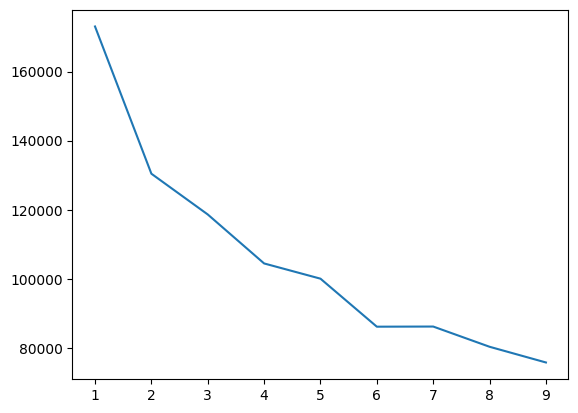

In [51]:
from sklearn.cluster import KMeans
kmeans_model = KMeans(n_clusters=3, random_state=42)
kmeans_model.fit(x_test)
kmeans_labels = kmeans_model.labels_
kmeans_score = kmeans_model.score(x_test)

print(kmeans_model.inertia_)

sse=[]
k_rng=range(1,10)
for k in k_rng:
    kmeans=KMeans(n_clusters=k)
    kmeans.fit(x_test)
    sse.append(kmeans.inertia_)
import matplotlib.pyplot as plt
plt.plot(k_rng,sse)